# 1. 커피OO 데이터 분석 

## 0. 환경 설정 및 데이터 로드


In [21]:
import pandas as pd 
import csv 
import os 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 
import koreanize_matplotlib

In [22]:
folder_path = os.path.join(os.getcwd(), 'data')
for file in os.listdir(folder_path):
    if file.startswith('d'):
        data_path = os.path.join(folder_path, file)
        raw_data = pd.read_csv(data_path)
cp_data_df = raw_data.copy()

In [23]:
# 데이터 확인 
cp_data_df.head()

,결제일시,결제일,결제년월,결제년,결제월,결제시간,결제시간대,요일,카테고리,수량,상품별 단가,상품명_추출,Hot/Ice,원두대분류,원두종류,원두용량,할인여부,취식 방법,매출
0,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,10000,과테말라 레드 파카마라,Hot,싱글,과테말라 레드 파카마라,-,-,-,10000
1,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,10500,콜롬비아 로꼬 소르베,Ice,싱글,콜롬비아 로꼬 소르베,-,-,-,10500
2,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,12000,니카라과 COE#1,Hot,싱글,니카라과 COE#1,-,-,-,12000
3,2022-02-10 10:13:57,2022-02-10,2022-02,2022,2,10:13:57,10,목요일,에스프레소,1,6500,슈퍼클린에스프레소,Hot,블렌딩,클래식,-,-,-,6500
4,2022-02-10 10:13:57,2022-02-10,2022-02,2022,2,10:13:57,10,목요일,에스프레소,1,6500,슈퍼클린에스프레소,Hot,블렌딩,쥬시,-,-,-,6500


In [24]:
cp_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153433 entries, 0 to 153432
Data columns (total 19 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   결제일시     153433 non-null  object
 1   결제일      153433 non-null  object
 2   결제년월     153433 non-null  object
 3   결제년      153433 non-null  int64 
 4   결제월      153433 non-null  int64 
 5   결제시간     153433 non-null  object
 6   결제시간대    153433 non-null  int64 
 7   요일       153433 non-null  object
 8   카테고리     153433 non-null  object
 9   수량       153433 non-null  int64 
 10  상품별 단가   153433 non-null  int64 
 11  상품명_추출   153433 non-null  object
 12  Hot/Ice  153433 non-null  object
 13  원두대분류    153433 non-null  object
 14  원두종류     153433 non-null  object
 15  원두용량     153433 non-null  object
 16  할인여부     153433 non-null  object
 17  취식 방법    153433 non-null  object
 18  매출       153433 non-null  int64 
dtypes: int64(6), object(13)
memory usage: 22.2+ MB


In [25]:
cp_data_df.shape

(153433, 19)

In [26]:
# 주말여부 컬럼 추가 
cp_data_df['주말 여부'] = np.where(cp_data_df['요일'].isin(['토요일', '일요일']), '주말', '평일')

# 계절 컬럼 추가 
cp_data_df['계절'] = np.where(cp_data_df['결제월'].isin([12, 1, 2]), '겨울',
                        np.where(cp_data_df['결제월'].isin([3, 4, 5]), '봄',
                        np.where(cp_data_df['결제월'].isin([6, 7, 8]), '여름', '가을')))

# 카페 운영시간 9시~18시 외 데이터 제거 
cp_data_df = cp_data_df.loc[~(cp_data_df['결제시간대'].isin([7, 8, 19, 18]))]

# "시" 단위 추가
cp_data_df['결제시간대'] = cp_data_df['결제시간대'].astype(str) + '시'

In [27]:
# 컬러 
sns.color_palette("Set3")

[(0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
 (1.0, 1.0, 0.7019607843137254),
 (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
 (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
 (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
 (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
 (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
 (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
 (0.7372549019607844, 0.5019607843137255, 0.7411764705882353),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (1.0, 0.9294117647058824, 0.43529411764705883)]

In [28]:
# 컬러 [파란색, 주황색]
colors1 = []
colors1.append(sns.color_palette("Set3")[5])
colors1.append(sns.color_palette("Set3")[4])

## 1-1. 카페 운영 시간과 매출의 관계 분석

### 1. 카페 월별 매출 추이

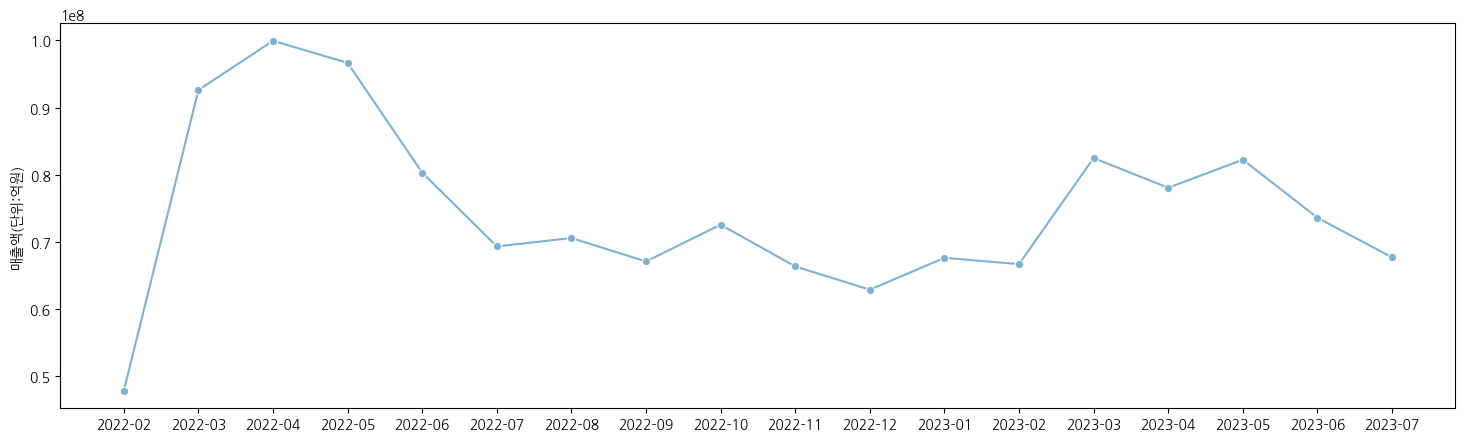

In [29]:
# 카페 월별 매출 추이
# 결제년월 기준으로 전체 매출을 합산해 월 단위 매출 흐름을 확인한다.
monthly_rev = cp_data_df.groupby(['결제년월'])['매출'].sum().reset_index(name='revenue')

# 월별 매출 추이 시각화
# x축은 월, y축은 월별 총매출이며 선 그래프로 매출 증감 흐름을 표현한다.
plt.figure(figsize=(18, 5))
sns.lineplot(data=monthly_rev, x='결제년월', y='revenue', marker='o', color=colors1[1])

plt.xlabel('')
plt.ylabel('매출액(단위:억원)')
plt.show()

### 2. 카페 시간대별 매출 추이 

#### 2-1. 카페 시간대별 누적 매출액 변화

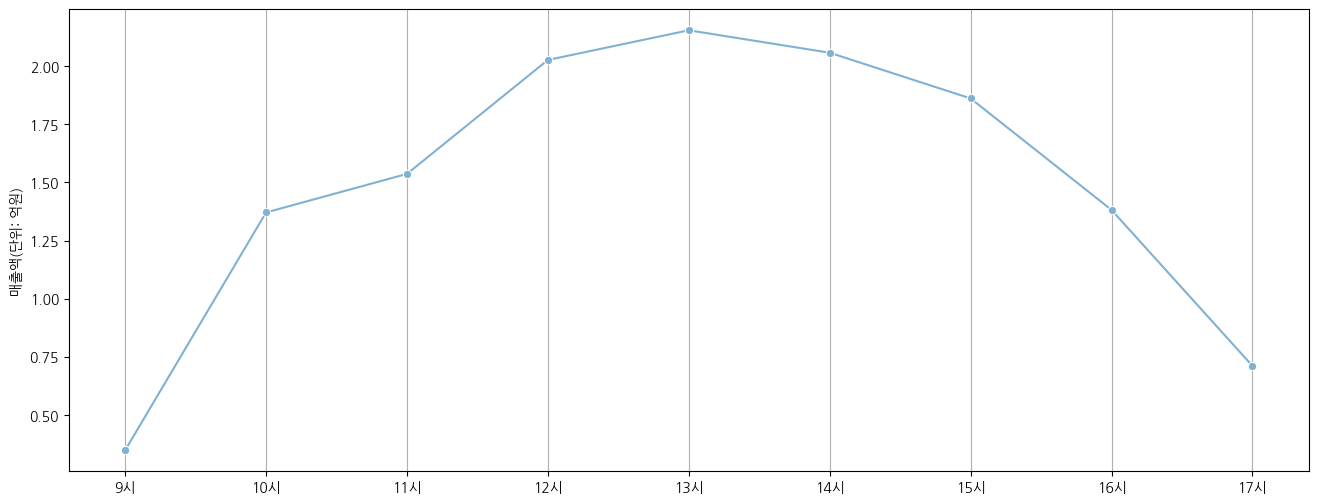

In [30]:
# 카페 시간대별 누적 매출
# 결제시간대별 전체 매출을 합산해 어느 시간대에 매출이 집중되는지 확인한다.
hourly_rev = cp_data_df.groupby('결제시간대')['매출'].sum().reset_index(name='매출')

# 시간대 순서 정의
# 문자열 시간대가 그래프에서 실제 영업시간 순서대로 표시되도록 순서를 지정한다.
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시']
hourly_rev['결제시간대'] = pd.Categorical(hourly_rev['결제시간대'], categories=hour_order, ordered=True)

# 시간대 순서대로 정렬
hourly_rev = hourly_rev.sort_values('결제시간대')

# 그래프 해석을 쉽게 하기 위해 매출 단위를 원에서 억원으로 변환
hourly_rev['매출'] = hourly_rev['매출'] / 1e8

# 시간대별 누적 매출 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(data=hourly_rev, x='결제시간대', y='매출', marker='o', color=colors1[1])

plt.xlabel('')
plt.ylabel('매출액(단위: 억원)')
plt.grid(axis='x')
plt.show()

In [31]:
# 시간대별 누적 매출 해석 메모
# 메인 영업 시간대의 평균 매출과 오픈/마감 시간대 매출을 비교해 운영시간 조정 가능성을 확인한다.
# 메인 시간대 평균 매출 = 202,533,975
# 오픈시간(9시)  매출 == 34,744,800
# 마감시간(17시) 매출 == 71,079,400

#### 2-2. 카페 평일/주말 시간대별 매출 변화 

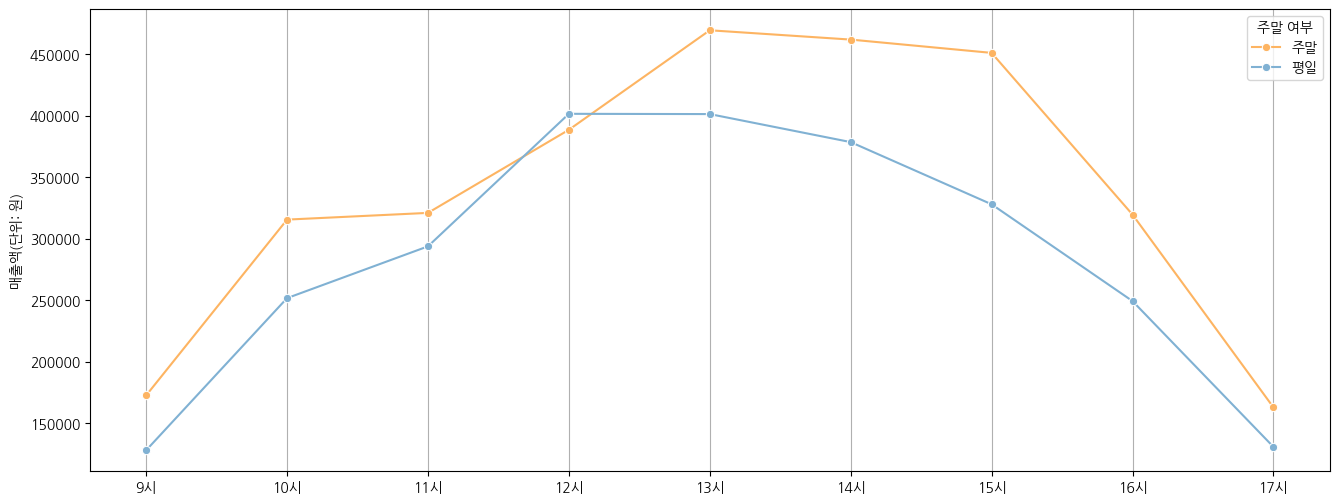

In [32]:
# 카페 시간대별 평일/주말 매출 변화
# 결제일, 결제시간대, 주말 여부별로 일 매출을 먼저 합산한다.
daily_hourly_weekend_rev = cp_data_df.groupby(['결제일', '결제시간대', '주말 여부'])['매출'].sum().reset_index(name='매출')

# 일별 합계 매출을 다시 시간대와 주말 여부 기준으로 평균내어 평일/주말의 시간대별 평균 매출을 구한다.
avg_hourly_weekend_rev = daily_hourly_weekend_rev.groupby(['결제시간대', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 시간대 순서 지정
# 카테고리형으로 변환해 그래프 x축이 9시부터 18시까지 순서대로 표시되게 한다.
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시']
avg_hourly_weekend_rev['결제시간대'] = pd.Categorical(avg_hourly_weekend_rev['결제시간대'], categories=hour_order, ordered=True)

# 시간대별 평일/주말 평균 매출 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(data=avg_hourly_weekend_rev, x='결제시간대', y='매출', hue='주말 여부', palette=colors1, marker='o')
plt.xlabel('')
plt.ylabel('매출액(단위: 원)')
plt.grid(axis='x')
plt.show()

#### 2-3. 시간대별 평일/주말 거래 건당 평균 금액

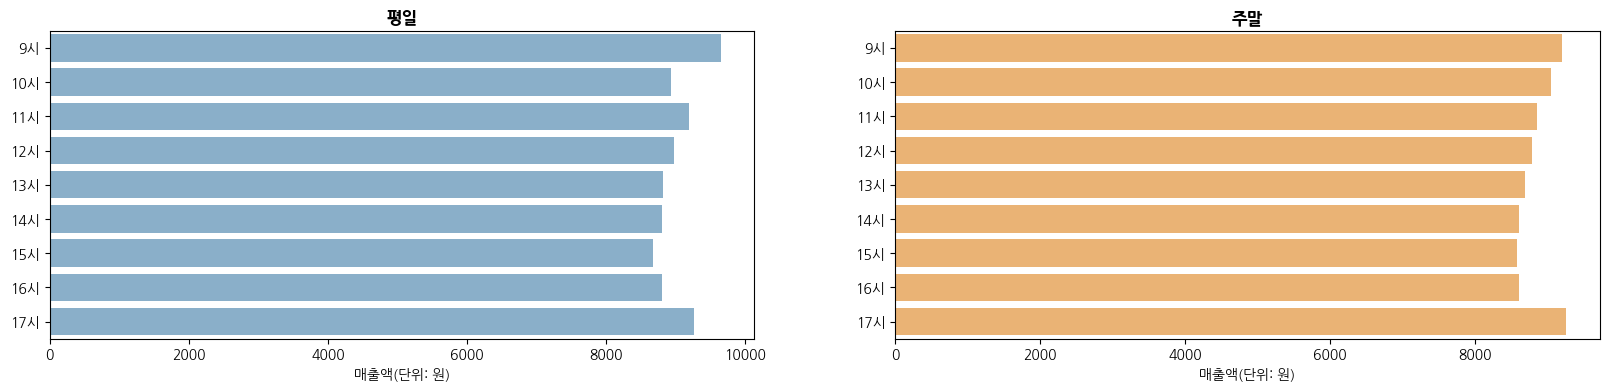

In [33]:
# 시간대별 평일/주말 거래 건당 평균 금액
# 결제시간대와 주말 여부를 기준으로 개별 거래의 평균 매출액을 계산한다.
avg_order_rev_by_hour_weekend = cp_data_df.groupby(['결제시간대', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 시간대 순서 지정
# 운영 시간 순서대로 막대그래프가 정렬되도록 카테고리 순서를 지정한다.
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시']
avg_order_rev_by_hour_weekend['결제시간대'] = pd.Categorical(avg_order_rev_by_hour_weekend['결제시간대'], categories=hour_order, ordered=True)

# 시간대별 평일/주말 거래 건당 평균 금액 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

# 평일 평균 거래금액 그래프
ax1 = axes[0]
sns.barplot(data=avg_order_rev_by_hour_weekend.loc[avg_order_rev_by_hour_weekend['주말 여부'] == '평일'], x='매출', y='결제시간대', ax=ax1, color=colors1[1])
ax1.set_title('평일', fontsize=12, weight='bold')
ax1.set_xlabel('매출액(단위: 원)', fontsize=10)
ax1.set_ylabel('')

# 주말 평균 거래금액 그래프
ax2 = axes[1]
sns.barplot(data=avg_order_rev_by_hour_weekend.loc[avg_order_rev_by_hour_weekend['주말 여부'] == '주말'], x='매출', y='결제시간대', ax=ax2, color=colors1[0])
ax2.set_title('주말', fontsize=12, weight='bold')
ax2.set_xlabel('매출액(단위: 원)', fontsize=10)
ax2.set_ylabel('')

plt.show()

### 3. 카페 요일별 매출 추이 

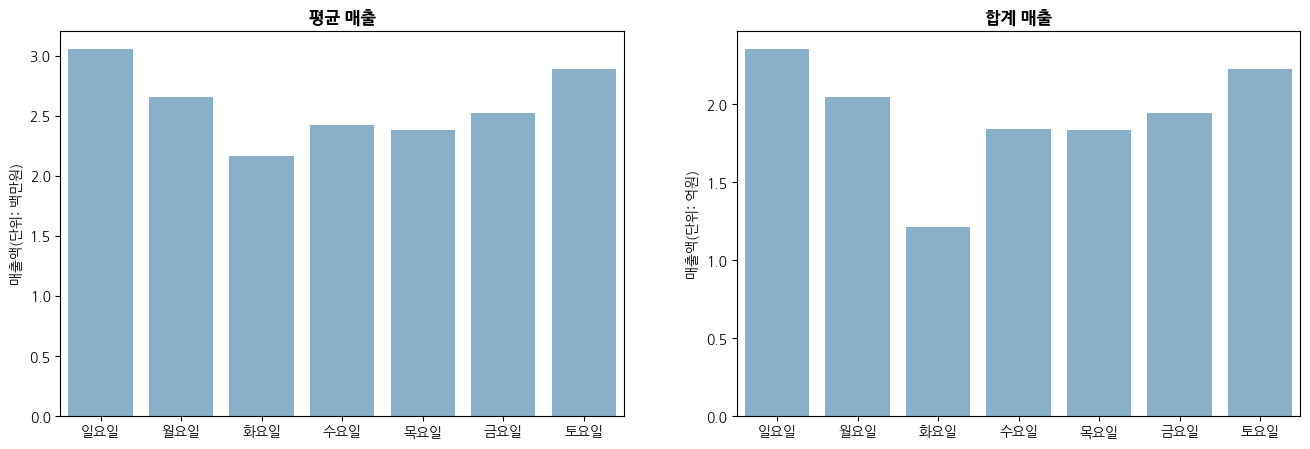

In [34]:
# 카페 요일별 매출 추이
# 요일이 그래프에서 일요일부터 토요일까지 고정된 순서로 표시되도록 순서를 지정한다.
day_order = ['일요일', '월요일', '화요일', '수요일', '목요일', '금요일', '토요일']

# 일별 요일 매출 집계
# 같은 결제일에 발생한 매출을 합산해 하루 단위 매출을 만든다.
daily_weekday_rev = cp_data_df.groupby(['결제일', '요일'])['매출'].sum().reset_index(name='매출')

# 요일별 평균 매출 집계
# 일별 매출을 요일 기준으로 평균내어 특정 요일의 일반적인 매출 수준을 확인한다.
avg_weekday_rev = daily_weekday_rev.groupby(['요일'])['매출'].mean().reset_index(name='매출')
avg_weekday_rev['요일'] = pd.Categorical(avg_weekday_rev['요일'], categories=day_order, ordered=True)

# 요일별 합계 매출 집계
# 전체 기간 동안 각 요일이 만든 총매출을 비교한다.
total_weekday_rev = cp_data_df.groupby(['요일'])['매출'].sum().reset_index(name='매출')
total_weekday_rev['요일'] = pd.Categorical(total_weekday_rev['요일'], categories=day_order, ordered=True)

# 그래프 해석을 쉽게 하기 위해 평균 매출은 백만원, 합계 매출은 억원 단위로 변환
avg_weekday_rev['매출'] = avg_weekday_rev['매출'] / 1e6
total_weekday_rev['매출'] = total_weekday_rev['매출'] / 1e8

# 요일별 평균 매출과 합계 매출 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 요일별 평균 매출액
ax1 = axes[0]
sns.barplot(data=avg_weekday_rev, x='요일', y='매출', ax=ax1, color=colors1[1])
ax1.set_title('평균 매출', fontsize=12, weight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('매출액(단위: 백만원)', fontsize=10)

# 요일별 합계 매출액
ax2 = axes[1]
sns.barplot(data=total_weekday_rev, x='요일', y='매출', ax=ax2, color=colors1[1])
ax2.set_title('합계 매출', fontsize=12, weight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('매출액(단위: 억원)', fontsize=10)

plt.show()

### 4. 계절별 매출 추이 

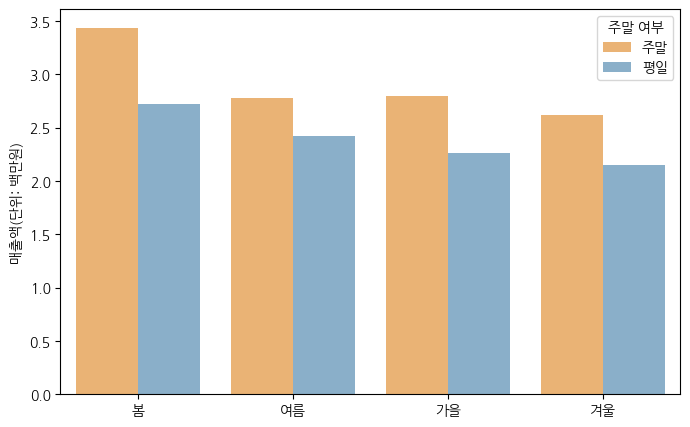

In [35]:
# 계절별 매출 추이
# 결제일, 계절, 주말 여부별로 하루 매출을 먼저 합산한다.
daily_season_weekend_rev = cp_data_df.groupby(['결제일', '계절', '주말 여부'])['매출'].sum().reset_index(name='매출')

# 계절과 주말 여부 기준으로 일평균 매출을 계산해 계절성 및 평일/주말 차이를 확인한다.
avg_season_weekend_rev = daily_season_weekend_rev.groupby(['계절', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 계절 순서 지정
# 그래프 x축이 봄, 여름, 가을, 겨울 순서로 표시되도록 카테고리 순서를 지정한다.
season_order = ['봄', '여름', '가을', '겨울']
avg_season_weekend_rev['계절'] = pd.Categorical(avg_season_weekend_rev['계절'], categories=season_order, ordered=True)

# 그래프 해석을 쉽게 하기 위해 매출 단위를 원에서 백만원으로 변환
avg_season_weekend_rev['매출'] = avg_season_weekend_rev['매출'] / 1e6

# 계절별 평일/주말 일평균 매출 시각화
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_season_weekend_rev, x='계절', y='매출', hue='주말 여부', palette=colors1)
plt.xlabel('')
plt.ylabel('매출액(단위: 백만원)', fontsize=10)

plt.show()

## 1-2. 카페 메뉴와 매출 관계 분석

### 1. 카테고리 및 제품별 매출 추이

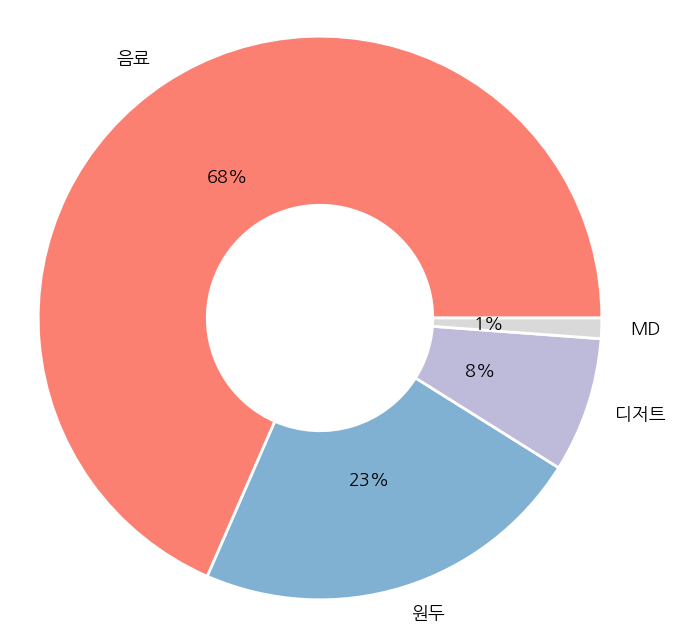

,메뉴 카테고리,매출
0,음료,915051500
1,원두,302506600
2,디저트,103539600
3,MD,15673000


In [41]:
# 카페 메뉴 대분류별 매출 비중 분석
# 기존 카테고리를 분석 목적에 맞게 음료/원두/디저트/MD로 재분류한다.
menu_category_map = {
    '핸드드립': '음료',
    '에스프레소': '음료',
    '시그니처': '음료',
    'Basic': '음료',
    '비버리지': '음료',
    '드립백/캡슐': '원두',
    '싱글원두': '원두',
    '블렌딩원두': '원두',
    '디저트': '디저트',
    'MD': 'MD',
}

# 세트/사업자 카테고리는 메뉴 대분류 매출 비중 분석 대상에서 제외한다.
menu_sales_df = cp_data_df.loc[~cp_data_df['카테고리'].isin(['세트', '사업자'])].copy()

# 매핑된 새 카테고리 컬럼을 추가하고, 지정한 대분류에 포함되지 않는 행은 제외한다.
menu_sales_df['메뉴 카테고리'] = menu_sales_df['카테고리'].map(menu_category_map)
menu_sales_df = menu_sales_df.dropna(subset=['메뉴 카테고리'])

# 메뉴 카테고리별 매출 합계를 계산한다.
menu_category_rev = (
    menu_sales_df
    .groupby('메뉴 카테고리')['매출']
    .sum()
    .reindex(['음료', '원두', '디저트', 'MD'])
    .reset_index(name='매출')
)

# Set3 팔레트에서 예시 이미지와 유사한 색을 선택한다.
set3_palette = sns.color_palette('Set3')
pie_colors = [set3_palette[3], set3_palette[4], set3_palette[2], set3_palette[8]]

# 카테고리별 매출 비중 도넛 파이 차트 시각화
plt.figure(figsize=(8, 8))
plt.pie(
    menu_category_rev['매출'],
    labels=menu_category_rev['메뉴 카테고리'],
    autopct='%.0f%%',
    startangle=0,
    counterclock=True,
    colors=pie_colors,
    wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13},
)

plt.axis('equal')
plt.show()

menu_category_rev

### 2. 음료 카테고리별 매출 월별 변화 

/var/folders/28/yfz0sdy50n5bhnthb4tg9j8m0000gn/T/ipykernel_85598/1208571212.py:21: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.lineplot(


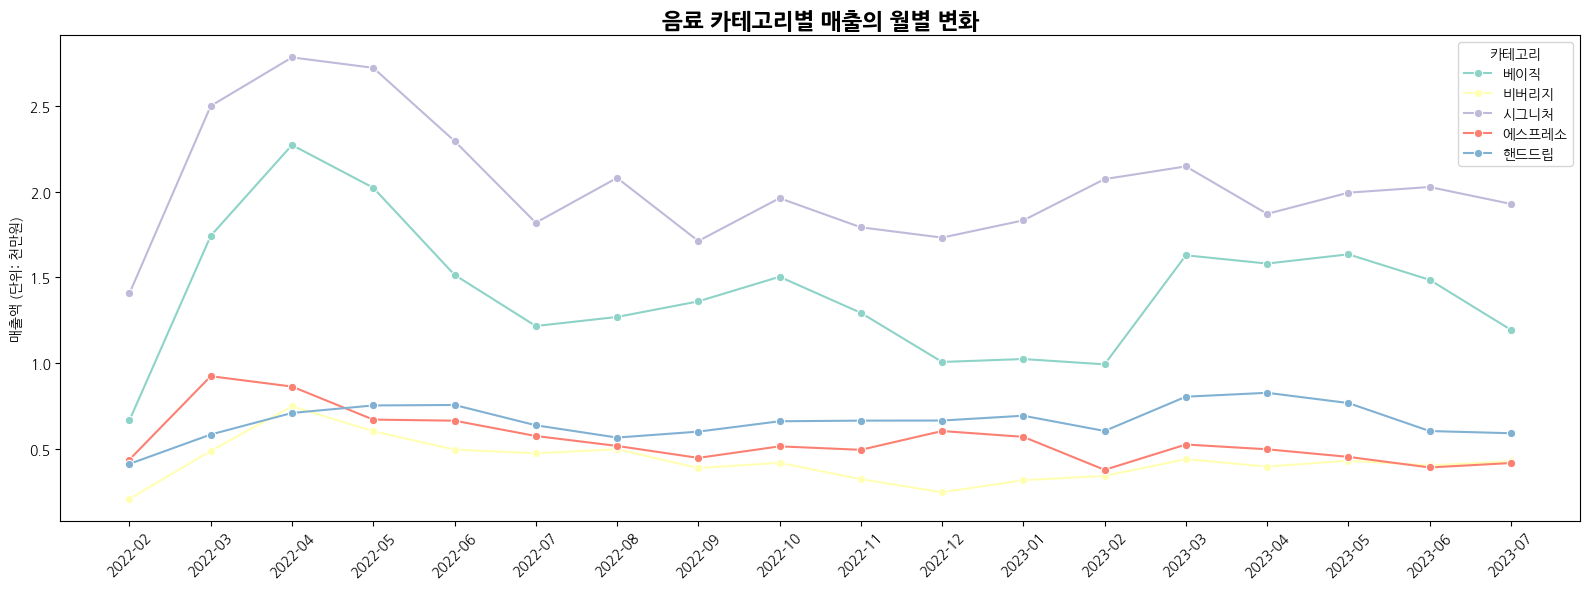

,결제년월,음료 카테고리,매출,매출_천만원
0,2022-02,베이직,6656000,0.66560
1,2022-02,비버리지,2067500,0.20675
2,2022-02,시그니처,14067000,1.40670
3,2022-02,에스프레소,4361500,0.43615
4,2022-02,핸드드립,4108000,0.41080
...,...,...,...,...
85,2023-07,베이직,11935500,1.19355
86,2023-07,비버리지,4260500,0.42605
87,2023-07,시그니처,19285000,1.92850
88,2023-07,에스프레소,4159000,0.41590


In [46]:
# 음료 카테고리별 매출 월별 변화
# menu_sales_df에서 메뉴 카테고리가 음료인 데이터만 추출한다.
beverage_sales_df = menu_sales_df.loc[menu_sales_df['메뉴 카테고리'] == '음료'].copy()

# 그래프 범례를 보기 쉽게 만들기 위해 Basic은 베이직으로 표기한다.
beverage_sales_df['음료 카테고리'] = beverage_sales_df['카테고리'].replace({'Basic': '베이직'})

# 결제년월과 음료 카테고리별 매출 합계를 계산한다.
monthly_beverage_category_rev = (
    beverage_sales_df
    .groupby(['결제년월', '음료 카테고리'])['매출']
    .sum()
    .reset_index(name='매출')
)

# 그래프 해석을 쉽게 하기 위해 매출 단위를 원에서 천만원으로 변환한다.
monthly_beverage_category_rev['매출_천만원'] = monthly_beverage_category_rev['매출'] / 1e7

# 음료 카테고리별 매출의 월별 변화 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=monthly_beverage_category_rev,
    x='결제년월',
    y='매출_천만원',
    hue='음료 카테고리',
    marker='o',
    palette=sns.color_palette('Set3'),
)

plt.title('음료 카테고리별 매출의 월별 변화', fontsize=16, weight='bold')
plt.xlabel('')
plt.ylabel('매출액 (단위: 천만원)')
plt.xticks(rotation=45)
plt.legend(title='카테고리')
plt.tight_layout()
plt.show()

monthly_beverage_category_rev

### 3. 음료 판매량 상위 20개 누적 판매량 

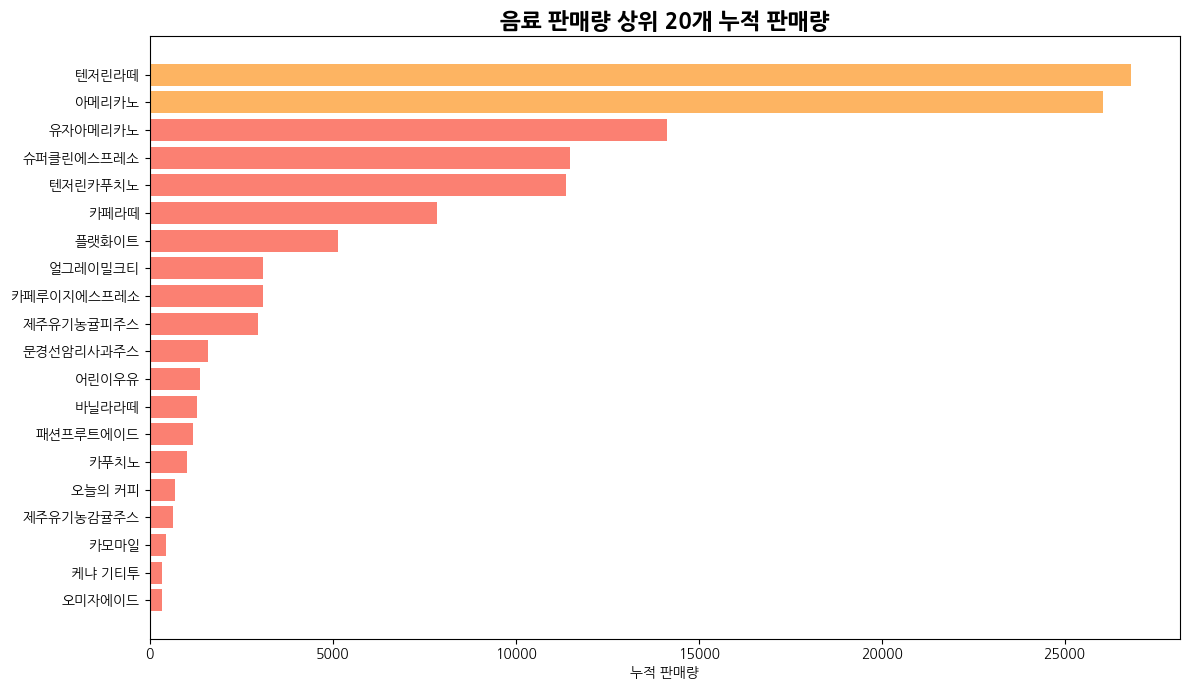

,상품명_추출,누적 판매량
0,텐저린라떼,26814
1,아메리카노,26051
2,유자아메리카노,14140
3,슈퍼클린에스프레소,11487
4,텐저린카푸치노,11389
5,카페라떼,7843
6,플랫화이트,5138
7,얼그레이밀크티,3102
8,카페루이지에스프레소,3088
9,제주유기농귤피주스,2970


In [47]:
# 음료 판매량 상위 20개 누적 판매량
# 음료 데이터에서 상품별 수량을 합산해 누적 판매량을 계산한다.
top20_beverage_qty = (
    beverage_sales_df
    .groupby('상품명_추출')['수량']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='누적 판매량')
)

# 판매량이 높은 상품이 위에 오도록 역순으로 정렬한다.
top20_beverage_qty_plot = top20_beverage_qty.sort_values('누적 판매량', ascending=True)

# 판매량 상위 2개 상품은 진한 색으로 강조하고, 나머지는 같은 계열의 연한 색으로 표시한다.
base_color = sns.color_palette('Set3')[3]
highlight_color = sns.color_palette('Set3')[5]
bar_colors = [
    highlight_color if product in top20_beverage_qty.head(2)['상품명_추출'].tolist() else base_color
    for product in top20_beverage_qty_plot['상품명_추출']
]

# 음료 판매량 상위 20개 상품의 누적 판매량 시각화
plt.figure(figsize=(12, 7))
plt.barh(top20_beverage_qty_plot['상품명_추출'], top20_beverage_qty_plot['누적 판매량'], color=bar_colors)

plt.title('음료 판매량 상위 20개 누적 판매량', fontsize=16, weight='bold')
plt.xlabel('누적 판매량')
plt.ylabel('')
plt.tight_layout()
plt.show()

top20_beverage_qty

### 4. 원두 카테고리별 매출의 월별 변화 

/var/folders/28/yfz0sdy50n5bhnthb4tg9j8m0000gn/T/ipykernel_85598/2164291718.py:18: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(


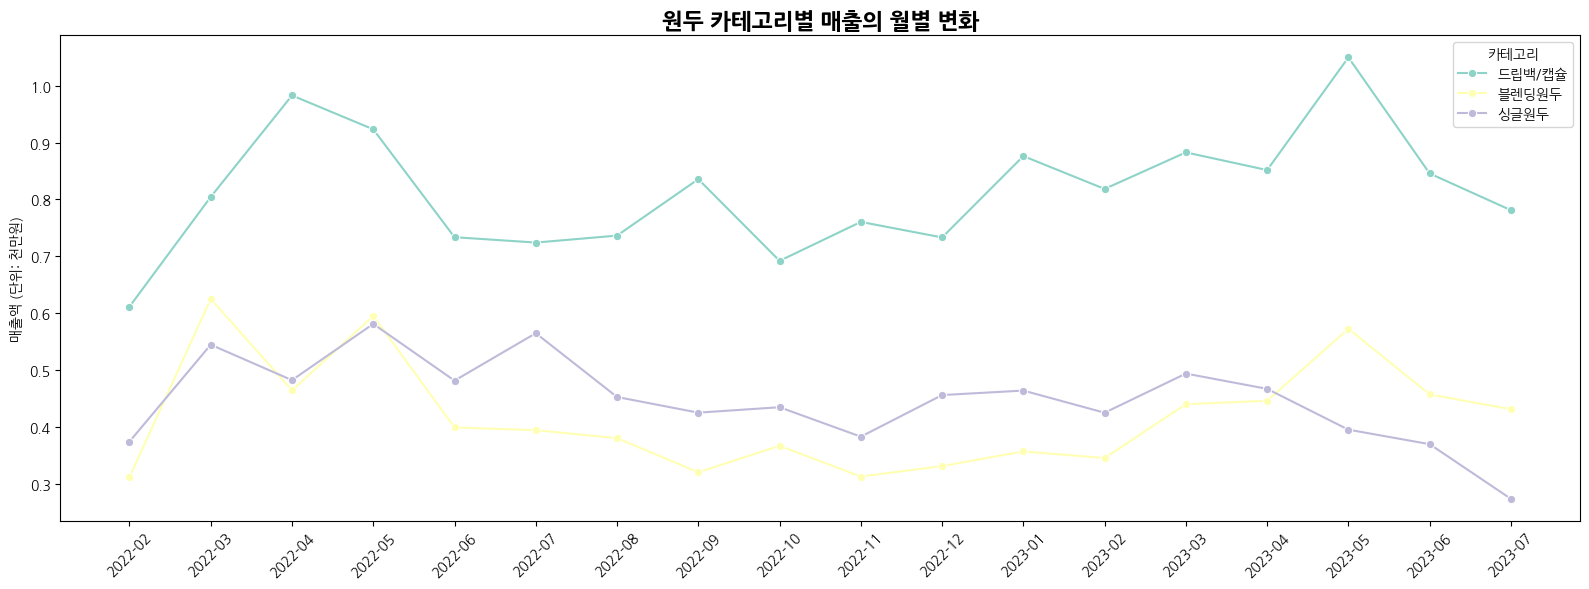

,결제년월,카테고리,매출,매출_천만원
0,2022-02,드립백/캡슐,6113000,0.61130
1,2022-02,블렌딩원두,3113000,0.31130
2,2022-02,싱글원두,3739000,0.37390
3,2022-03,드립백/캡슐,8044000,0.80440
4,2022-03,블렌딩원두,6250000,0.62500
5,2022-03,싱글원두,5444000,0.54440
6,2022-04,드립백/캡슐,9829000,0.98290
7,2022-04,블렌딩원두,4640000,0.46400
8,2022-04,싱글원두,4820000,0.48200
9,2022-05,드립백/캡슐,9233000,0.92330


In [48]:
# 원두 카테고리별 매출 월별 변화
# menu_sales_df에서 메뉴 카테고리가 원두인 데이터만 추출한다.
bean_sales_df = menu_sales_df.loc[menu_sales_df['메뉴 카테고리'] == '원두'].copy()

# 결제년월과 원두 카테고리별 매출 합계를 계산한다.
monthly_bean_category_rev = (
    bean_sales_df
    .groupby(['결제년월', '카테고리'])['매출']
    .sum()
    .reset_index(name='매출')
)

# 그래프 해석을 쉽게 하기 위해 매출 단위를 원에서 천만원으로 변환한다.
monthly_bean_category_rev['매출_천만원'] = monthly_bean_category_rev['매출'] / 1e7

# 원두 카테고리별 매출의 월별 변화 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=monthly_bean_category_rev,
    x='결제년월',
    y='매출_천만원',
    hue='카테고리',
    marker='o',
    palette=sns.color_palette('Set3'),
)

plt.title('원두 카테고리별 매출의 월별 변화', fontsize=16, weight='bold')
plt.xlabel('')
plt.ylabel('매출액 (단위: 천만원)')
plt.xticks(rotation=45)
plt.legend(title='카테고리')
plt.tight_layout()
plt.show()

monthly_bean_category_rev

### 5. 원두 판매량 상위 20개 누적 판매량 

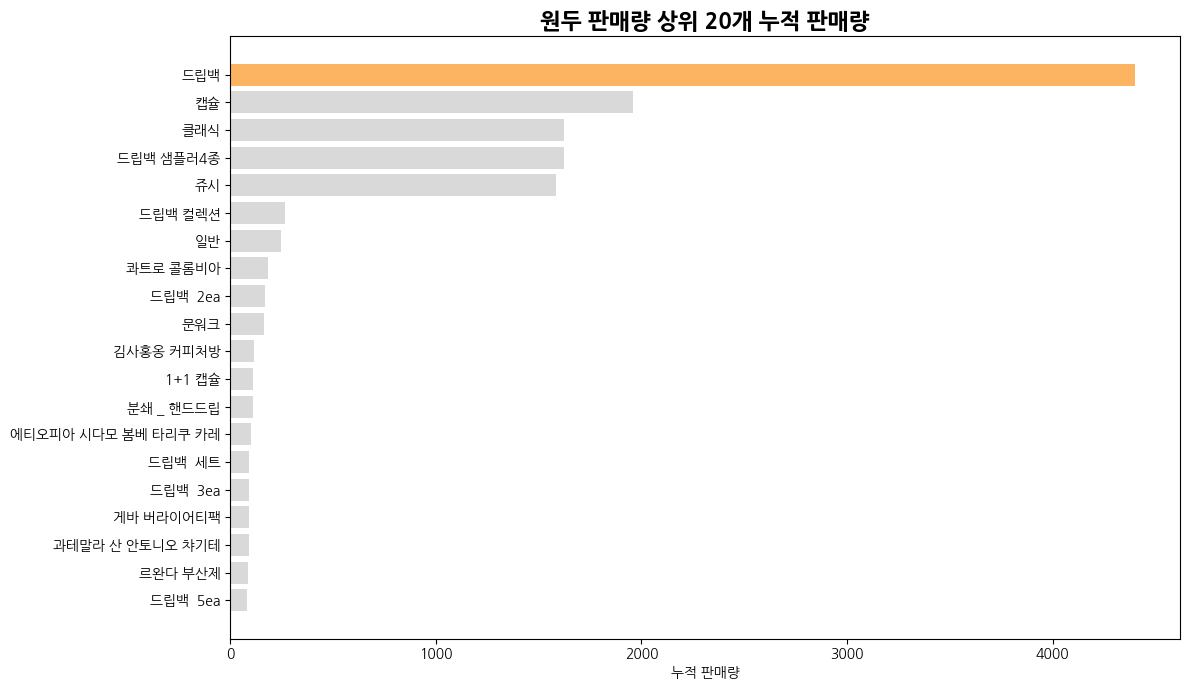

,상품명_추출,누적 판매량
0,드립백,4400
1,캡슐,1958
2,클래식,1626
3,드립백 샘플러4종,1623
4,쥬시,1585
5,드립백 컬렉션,266
6,일반,246
7,콰트로 콜롬비아,184
8,드립백 2ea,168
9,문워크,165


In [49]:
# 원두 판매량 상위 20개 누적 판매량
# 원두 데이터에서 상품별 수량을 합산해 누적 판매량을 계산한다.
top20_bean_qty = (
    bean_sales_df
    .groupby('상품명_추출')['수량']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='누적 판매량')
)

# 판매량이 높은 상품이 위에 오도록 역순으로 정렬한다.
top20_bean_qty_plot = top20_bean_qty.sort_values('누적 판매량', ascending=True)

# 판매량 1위 상품은 진한 색으로 강조하고, 나머지는 같은 계열의 연한 색으로 표시한다.
base_color = sns.color_palette('Set3')[8]
highlight_color = sns.color_palette('Set3')[5]
bar_colors = [
    highlight_color if product == top20_bean_qty.iloc[0]['상품명_추출'] else base_color
    for product in top20_bean_qty_plot['상품명_추출']
]

# 원두 판매량 상위 20개 상품의 누적 판매량 시각화
plt.figure(figsize=(12, 7))
plt.barh(top20_bean_qty_plot['상품명_추출'], top20_bean_qty_plot['누적 판매량'], color=bar_colors)

plt.title('원두 판매량 상위 20개 누적 판매량', fontsize=16, weight='bold')
plt.xlabel('누적 판매량')
plt.ylabel('')
plt.tight_layout()
plt.show()

top20_bean_qty

### 6. 음료 카테고리별 음료 매출 구성 비율의 월별 변화

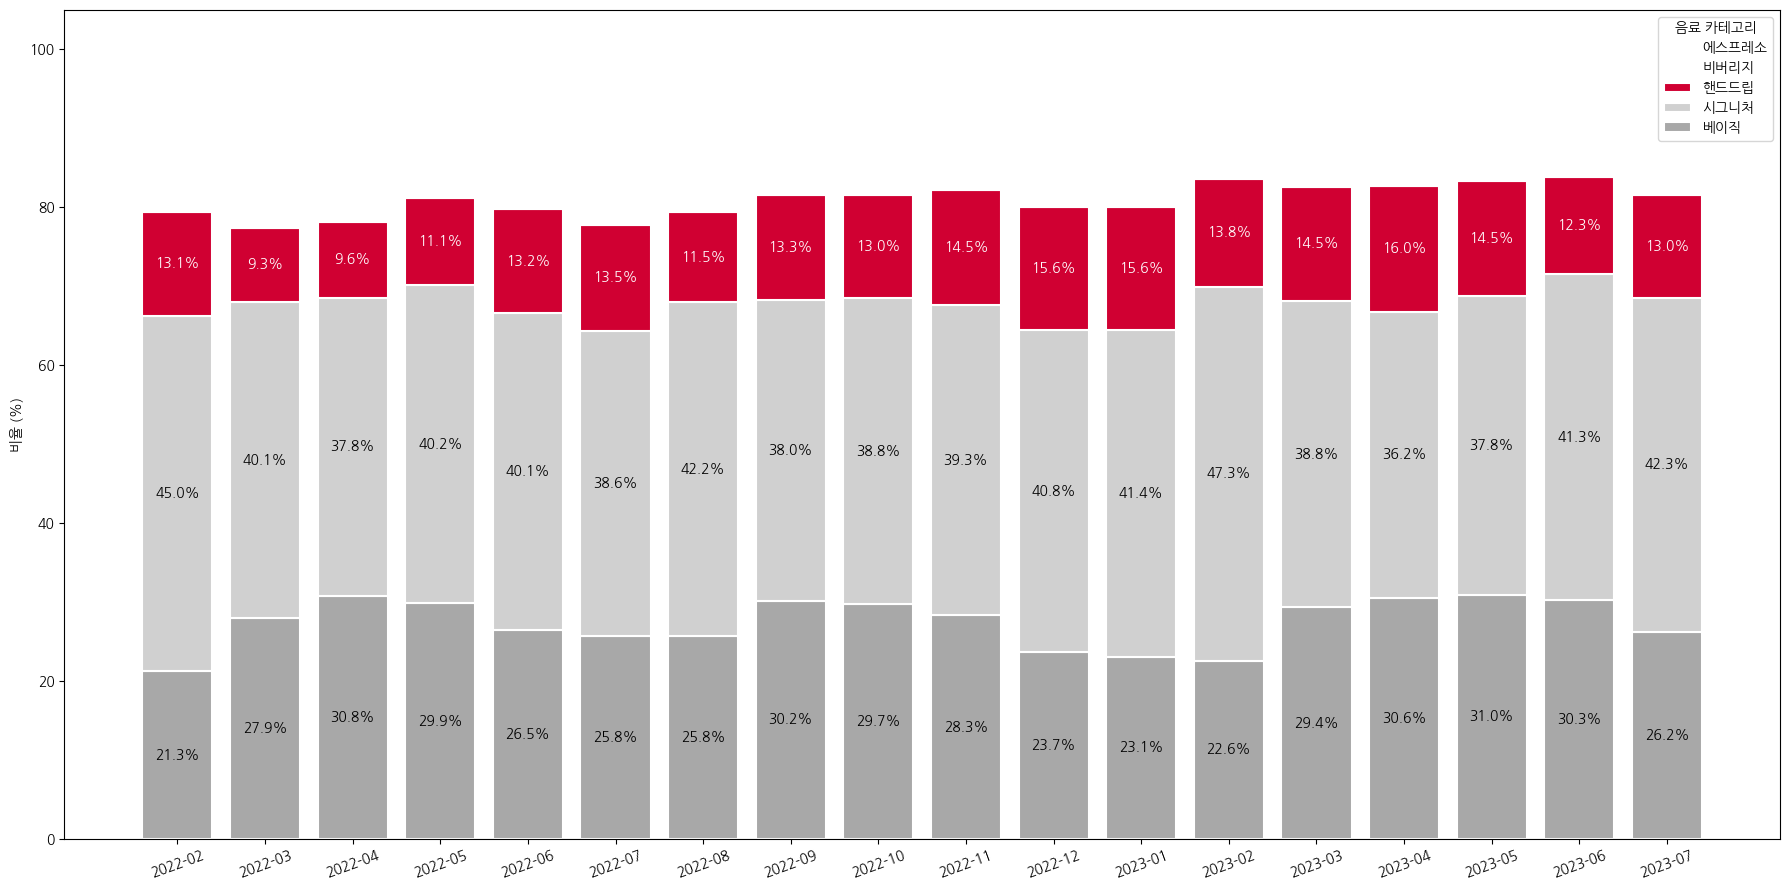

,결제년월,음료 카테고리,매출,비율
0,2022-02,베이직,6656000,21.292386
1,2022-02,비버리지,2067500,6.613884
2,2022-02,시그니처,14067000,45.000000
3,2022-02,에스프레소,4361500,13.952335
4,2022-02,핸드드립,4108000,13.141395
...,...,...,...,...
85,2023-07,베이직,11935500,26.209691
86,2023-07,비버리지,4260500,9.355820
87,2023-07,시그니처,19285000,42.348782
88,2023-07,에스프레소,4159000,9.132931


In [50]:
# 음료 카테고리별 음료 매출 구성 비율의 월별 변화
# menu_sales_df에서 메뉴 카테고리가 음료인 데이터만 사용한다.
beverage_ratio_df = menu_sales_df.loc[menu_sales_df['메뉴 카테고리'] == '음료'].copy()

# 그래프 표기명을 참고 이미지와 맞추기 위해 Basic은 베이직으로 변경한다.
beverage_ratio_df['음료 카테고리'] = beverage_ratio_df['카테고리'].replace({'Basic': '베이직'})

# 월별 음료 카테고리 매출을 집계한다.
monthly_beverage_ratio_rev = (
    beverage_ratio_df
    .groupby(['결제년월', '음료 카테고리'])['매출']
    .sum()
    .reset_index(name='매출')
)

# 월별 전체 음료 매출 대비 각 음료 카테고리의 매출 비율을 계산한다.
monthly_beverage_ratio_rev['비율'] = (
    monthly_beverage_ratio_rev['매출']
    / monthly_beverage_ratio_rev.groupby('결제년월')['매출'].transform('sum')
    * 100
)

# 누적 막대 그래프를 그리기 위해 월별 비율 데이터를 wide 형태로 변환한다.
# 에스프레소와 비버리지는 100% 기준에는 포함하되, 흰색으로 상단에 쌓아 화면에서 강조하지 않는다.
beverage_stack_order = ['베이직', '시그니처', '핸드드립', '비버리지', '에스프레소']
monthly_beverage_ratio_plot = (
    monthly_beverage_ratio_rev
    .pivot(index='결제년월', columns='음료 카테고리', values='비율')
    .reindex(columns=beverage_stack_order)
    .fillna(0)
)

# 참고 이미지와 유사하게 베이직/시그니처/핸드드립만 색을 부여하고 나머지는 흰색으로 처리한다.
beverage_ratio_colors = {
    '베이직': '#a8a8a8',
    '시그니처': '#d0d0d0',
    '핸드드립': '#d00032',
    '비버리지': '#ffffff',
    '에스프레소': '#ffffff',
}

# 월별 구성 비율 100% 누적 막대 그래프 시각화
fig, ax = plt.subplots(figsize=(18, 9))
bottom = np.zeros(len(monthly_beverage_ratio_plot))
x = np.arange(len(monthly_beverage_ratio_plot.index))

for category in beverage_stack_order:
    values = monthly_beverage_ratio_plot[category].values
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=category,
        color=beverage_ratio_colors[category],
        edgecolor='white',
        linewidth=1.5,
    )

    # 핸드드립, 시그니처, 베이직만 비율 라벨을 표시한다.
    if category in ['핸드드립', '시그니처', '베이직']:
        for bar, value, start in zip(bars, values, bottom):
            if value > 0:
                text_color = 'white' if category == '핸드드립' else 'black'
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    start + value / 2,
                    f'{value:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=10,
                    color=text_color,
                )

    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(monthly_beverage_ratio_plot.index, rotation=20)
ax.set_ylim(0, 105)
ax.set_ylabel('비율 (%)')

# 범례는 참고 이미지처럼 상단 카테고리부터 보이도록 순서를 뒤집는다.
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='음료 카테고리', loc='upper right')

plt.tight_layout()
plt.show()

monthly_beverage_ratio_rev

### 7. 핸드드립 카테고리의 월별 메뉴 수 

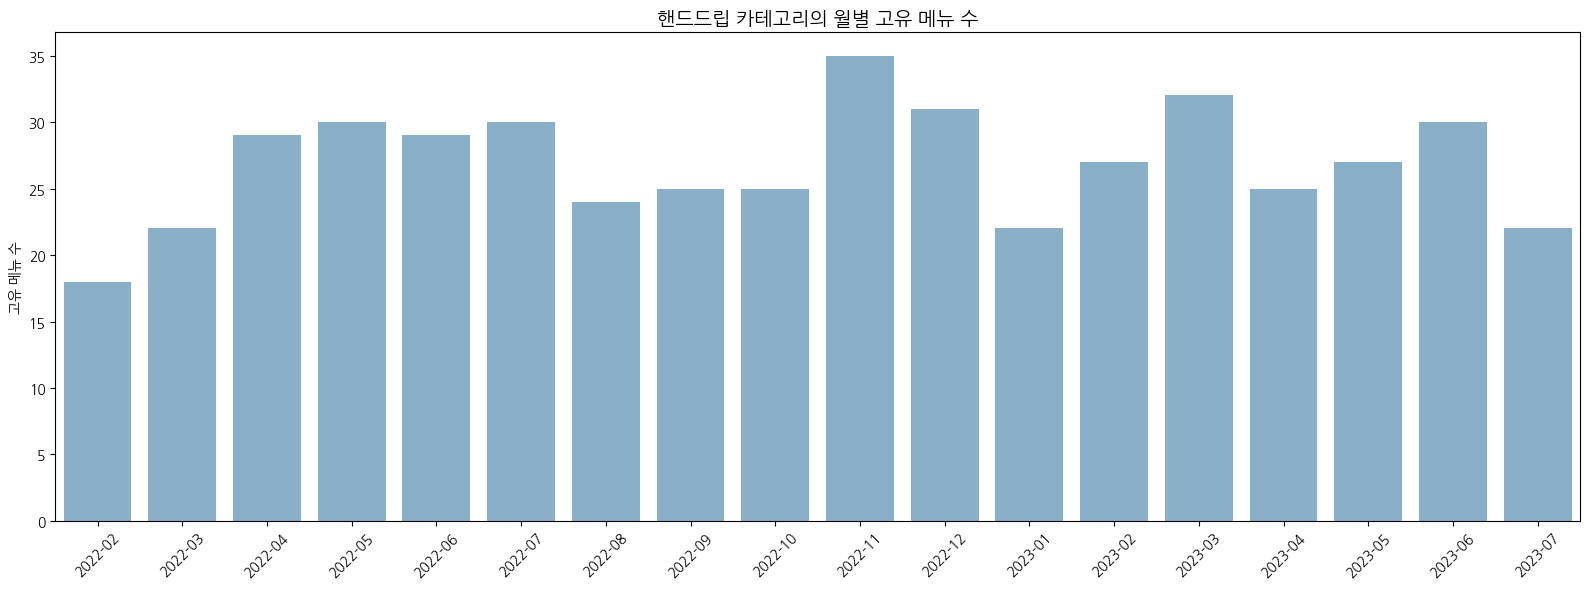

,결제년월,고유 메뉴 수
0,2022-02,18
1,2022-03,22
2,2022-04,29
3,2022-05,30
4,2022-06,29
5,2022-07,30
6,2022-08,24
7,2022-09,25
8,2022-10,25
9,2022-11,35


In [51]:
# 핸드드립 카테고리의 월별 메뉴 수
# 음료 데이터 중 핸드드립 카테고리만 추출한다.
handdrip_sales_df = beverage_sales_df.loc[beverage_sales_df['카테고리'] == '핸드드립'].copy()

# 결제년월별로 판매된 핸드드립 고유 메뉴 수를 계산한다.
monthly_handdrip_menu_cnt = (
    handdrip_sales_df
    .groupby('결제년월')['상품명_추출']
    .nunique()
    .reset_index(name='고유 메뉴 수')
)

# 핸드드립 월별 고유 메뉴 수 시각화
plt.figure(figsize=(16, 6))
sns.barplot(
    data=monthly_handdrip_menu_cnt,
    x='결제년월',
    y='고유 메뉴 수',
    color=sns.color_palette('Set3')[4],
)

plt.title('핸드드립 카테고리의 월별 고유 메뉴 수', fontsize=14)
plt.xlabel('')
plt.ylabel('고유 메뉴 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_handdrip_menu_cnt

### 8. 핸드드립 카테고리의 메뉴별 판매일 수

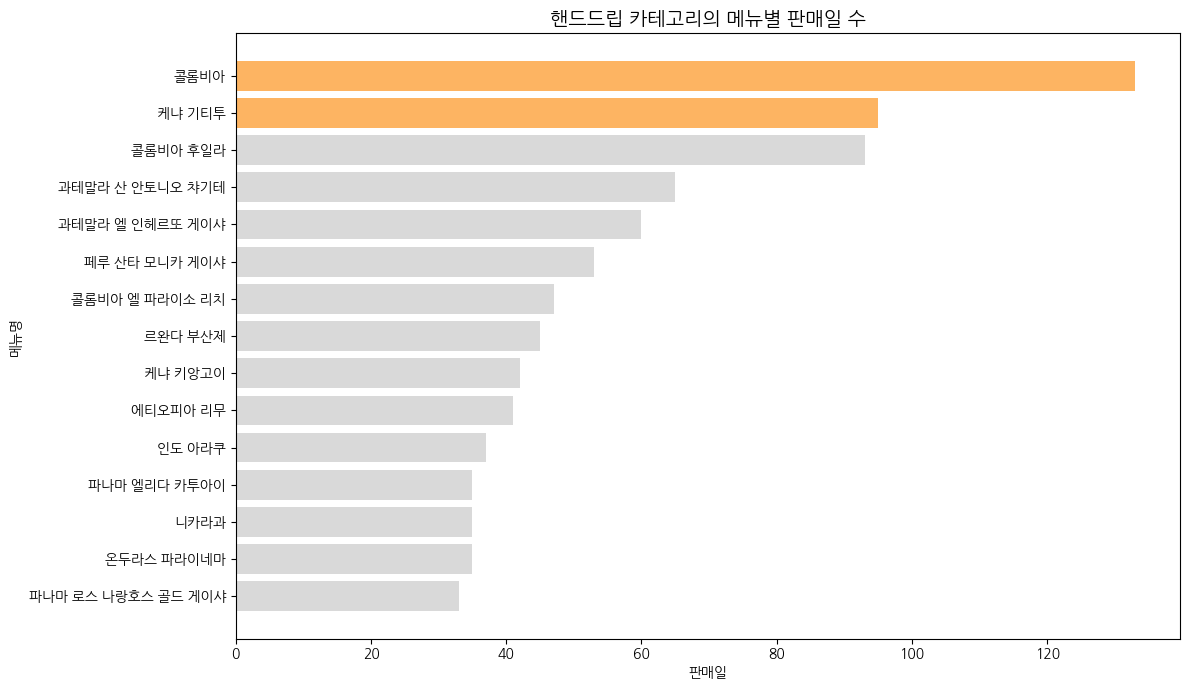

,상품명_추출,판매일
0,콜롬비아,133
1,케냐 기티투,95
2,콜롬비아 후일라,93
3,과테말라 산 안토니오 챠기테,65
4,과테말라 엘 인헤르또 게이샤,60
...,...,...
235,코스타리카 돈 마요 게이샤,1
236,코스타리카 산타 로사 1900 핀카 마초,1
237,과테말라 챠기테 카투라,1
238,콜롬비아 로꼬 소르베,1


In [53]:
# 핸드드립 카테고리의 메뉴별 판매일 수
# '오늘의 커피'는 상시 판매 메뉴에 가까워 개별 핸드드립 메뉴 판매일 수 비교에서 제외한다.
handdrip_menu_sales_day_df = handdrip_sales_df.loc[handdrip_sales_df['상품명_추출'] != '오늘의 커피'].copy()

# 핸드드립 메뉴별로 판매가 발생한 고유 결제일 수를 계산한다.
handdrip_menu_sales_day_cnt = (
    handdrip_menu_sales_day_df
    .groupby('상품명_추출')['결제일']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='판매일')
)

# 판매일 수가 많은 메뉴가 위에 오도록 상위 15개를 역순으로 정렬한다.
top_handdrip_menu_sales_day_cnt = handdrip_menu_sales_day_cnt.head(15)
top_handdrip_menu_sales_day_plot = top_handdrip_menu_sales_day_cnt.sort_values('판매일', ascending=True)

# 판매일 수 상위 2개 메뉴는 진한 색으로 강조하고, 나머지는 같은 계열의 연한 색으로 표시한다.
base_color = sns.color_palette('Set3')[8]
highlight_color = sns.color_palette('Set3')[5]
bar_colors = [
    highlight_color if menu in top_handdrip_menu_sales_day_cnt.head(2)['상품명_추출'].tolist() else base_color
    for menu in top_handdrip_menu_sales_day_plot['상품명_추출']
]

# 핸드드립 메뉴별 판매일 수 시각화
plt.figure(figsize=(12, 7))
plt.barh(
    top_handdrip_menu_sales_day_plot['상품명_추출'],
    top_handdrip_menu_sales_day_plot['판매일'],
    color=bar_colors,
)

plt.title('핸드드립 카테고리의 메뉴별 판매일 수', fontsize=14)
plt.xlabel('판매일')
plt.ylabel('메뉴명')
plt.tight_layout()
plt.show()

handdrip_menu_sales_day_cnt

### 9. 음료별 하루 평균 매출 추이 

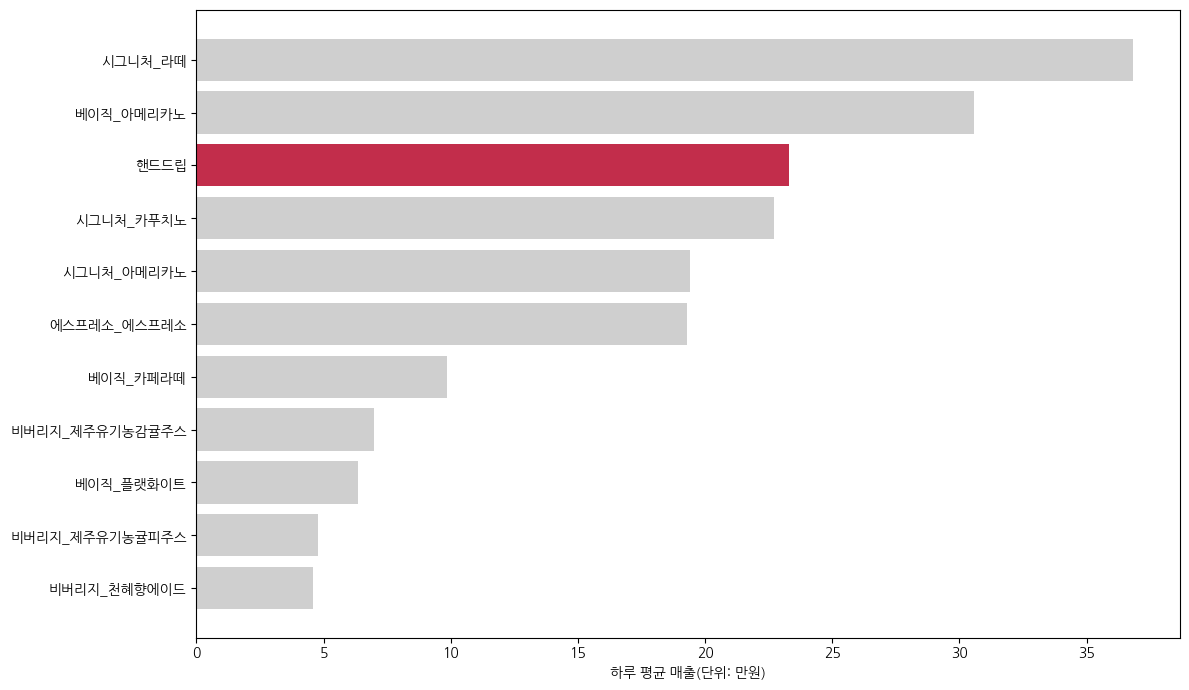

,음료명,하루 평균 매출
0,시그니처_라떼,368336.274510
1,베이직_아메리카노,305797.058824
2,핸드드립,232901.960784
3,시그니처_카푸치노,227283.475783
4,시그니처_아메리카노,194203.921569
5,에스프레소_에스프레소,192793.137255
6,베이직_카페라떼,98508.806262
7,비버리지_제주유기농감귤주스,70043.103448
8,베이직_플랫화이트,63415.686275
9,비버리지_제주유기농귤피주스,47903.225806


In [65]:
# 음료별 하루 평균 매출 추이
# 음료 카테고리 데이터에서 분석용 음료명을 생성한다.
daily_beverage_rev_df = beverage_sales_df.copy()

# 참고 그래프처럼 핸드드립은 개별 원두명이 아니라 하나의 음료군으로 묶는다.
# Basic은 베이직으로 표기하고, 시그니처 메뉴는 라떼/카푸치노/아메리카노 단위로 간단히 정리한다.
def make_beverage_name(row):
    category = row['카테고리']
    product = row['상품명_추출']

    if category == '핸드드립':
        return '핸드드립'
    if category == 'Basic':
        return f'베이직_{product}'
    if category == '시그니처':
        product = product.replace('텐저린라떼', '라떼')
        product = product.replace('텐저린카푸치노', '카푸치노')
        product = product.replace('유자아메리카노', '아메리카노')
        return f'시그니처_{product}'
    if category == '에스프레소':
        product = product.replace('슈퍼클린에스프레소', '에스프레소')
        product = product.replace('카페루이지에스프레소', '에스프레소')
        return f'에스프레소_{product}'
    if category == '비버리지':
        return f'비버리지_{product}'
    return product


daily_beverage_rev_df['음료명'] = daily_beverage_rev_df.apply(make_beverage_name, axis=1)

# 결제일과 음료명별 매출을 먼저 합산한 뒤, 음료별 하루 평균 매출을 계산한다.
daily_beverage_rev = (
    daily_beverage_rev_df
    .groupby(['결제일', '음료명'])['매출']
    .sum()
    .reset_index(name='일매출')
)

avg_daily_beverage_rev = (
    daily_beverage_rev
    .groupby('음료명')['일매출']
    .mean()
    .sort_values(ascending=False)
    .head(11)
    .reset_index(name='하루 평균 매출')
)

# 그래프에서 매출이 큰 음료가 위에 오도록 역순으로 정렬하고, 단위는 만원으로 변환한다.
avg_daily_beverage_rev_plot = avg_daily_beverage_rev.sort_values('하루 평균 매출', ascending=True).copy()
avg_daily_beverage_rev_plot['하루 평균 매출_만원'] = avg_daily_beverage_rev_plot['하루 평균 매출'] / 1e4

# 핸드드립만 강조색으로 표시하고 나머지는 회색으로 표시한다.
bar_colors = [
    '#c22d4b' if beverage == '핸드드립' else '#cfcfcf'
    for beverage in avg_daily_beverage_rev_plot['음료명']
]

# 음료별 하루 평균 매출 시각화
plt.figure(figsize=(12, 7))
plt.barh(
    avg_daily_beverage_rev_plot['음료명'],
    avg_daily_beverage_rev_plot['하루 평균 매출_만원'],
    color=bar_colors,
)

plt.xlabel('하루 평균 매출(단위: 만원)')
plt.ylabel('')
plt.tight_layout()
plt.show()

avg_daily_beverage_rev

### 10. 에스프레소 카테고리 매출 월별 변화

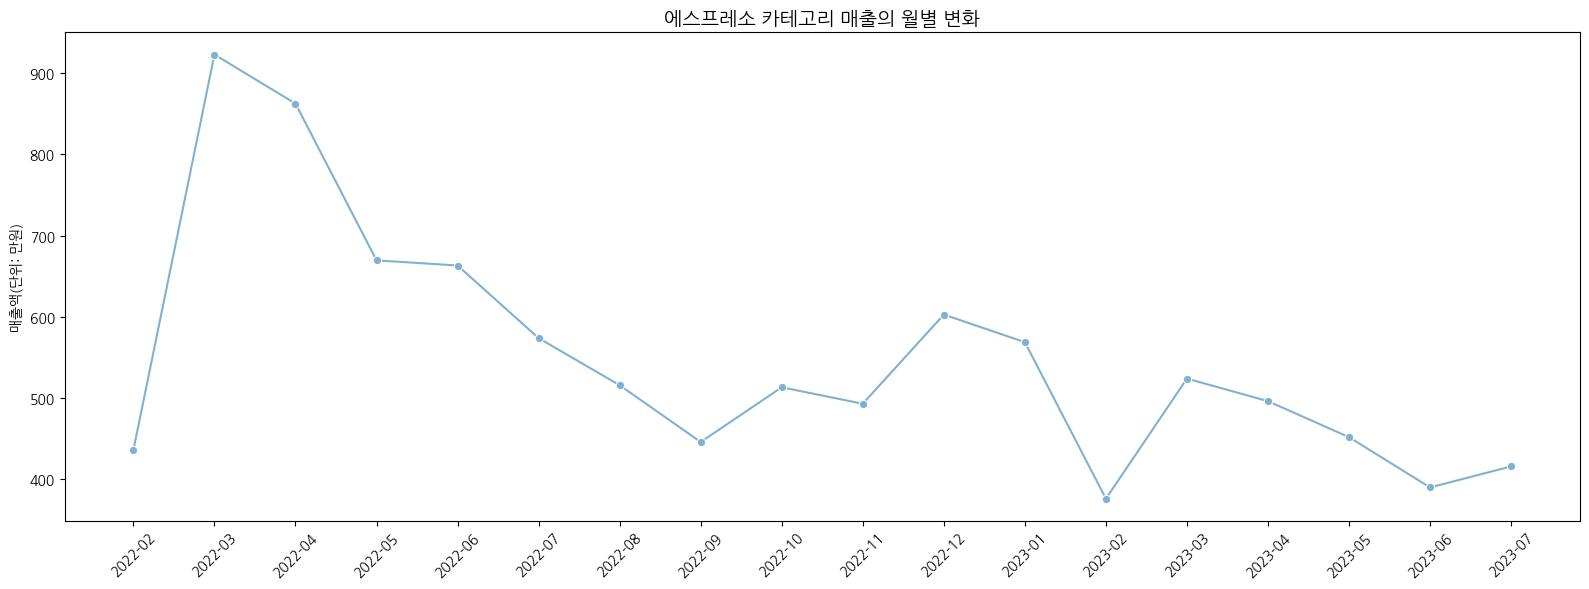

,결제년월,매출,매출_만원
0,2022-02,4361500,436.15
1,2022-03,9228000,922.80
2,2022-04,8624000,862.40
3,2022-05,6694500,669.45
4,2022-06,6631500,663.15
5,2022-07,5737500,573.75
6,2022-08,5158000,515.80
7,2022-09,4459000,445.90
8,2022-10,5132500,513.25
9,2022-11,4930000,493.00


In [68]:
# 에스프레소 카테고리 매출 월별 변화
# 음료 데이터 중 에스프레소 카테고리만 추출한다.
espresso_sales_df = beverage_sales_df.loc[beverage_sales_df['카테고리'] == '에스프레소'].copy()

# 결제일을 datetime으로 변환하고, 이후 분기별 분석에서도 사용할 결제분기 컬럼을 만든다.
espresso_sales_df['결제일'] = pd.to_datetime(espresso_sales_df['결제일'])
espresso_sales_df['결제분기'] = (
    espresso_sales_df['결제일'].dt.year.astype(str)
    + '년 '
    + espresso_sales_df['결제일'].dt.quarter.astype(str)
    + '분기'
)

# 다음 에스프레소 메뉴별 분기 비중 그래프에서 사용할 분기 순서를 미리 정의한다.
quarter_order = espresso_sales_df.sort_values('결제일')['결제분기'].drop_duplicates().tolist()

# 월별 에스프레소 총매출을 집계한다.
monthly_espresso_rev = (
    espresso_sales_df
    .groupby('결제년월')['매출']
    .sum()
    .reset_index(name='매출')
)

# 월 라벨이 시간 순서대로 표시되도록 정렬한다.
month_order = espresso_sales_df.sort_values('결제일')['결제년월'].drop_duplicates().tolist()
monthly_espresso_rev['결제년월'] = pd.Categorical(monthly_espresso_rev['결제년월'], categories=month_order, ordered=True)
monthly_espresso_rev = monthly_espresso_rev.sort_values('결제년월')

# 그래프 해석을 쉽게 하기 위해 매출 단위를 원에서 만원으로 변환한다.
monthly_espresso_rev['매출_만원'] = monthly_espresso_rev['매출'] / 1e4

# 에스프레소 카테고리 매출의 월별 변화 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=monthly_espresso_rev,
    x='결제년월',
    y='매출_만원',
    marker='o',
    color=sns.color_palette('Set3')[4],
)

plt.title('에스프레소 카테고리 매출의 월별 변화', fontsize=14)
plt.xlabel('')
plt.ylabel('매출액(단위: 만원)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_espresso_rev

### 11. 에스프레소 카테고리 메뉴별 매출 비중 분기별 변화 

/var/folders/28/yfz0sdy50n5bhnthb4tg9j8m0000gn/T/ipykernel_85598/660397696.py:34: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  sns.lineplot(


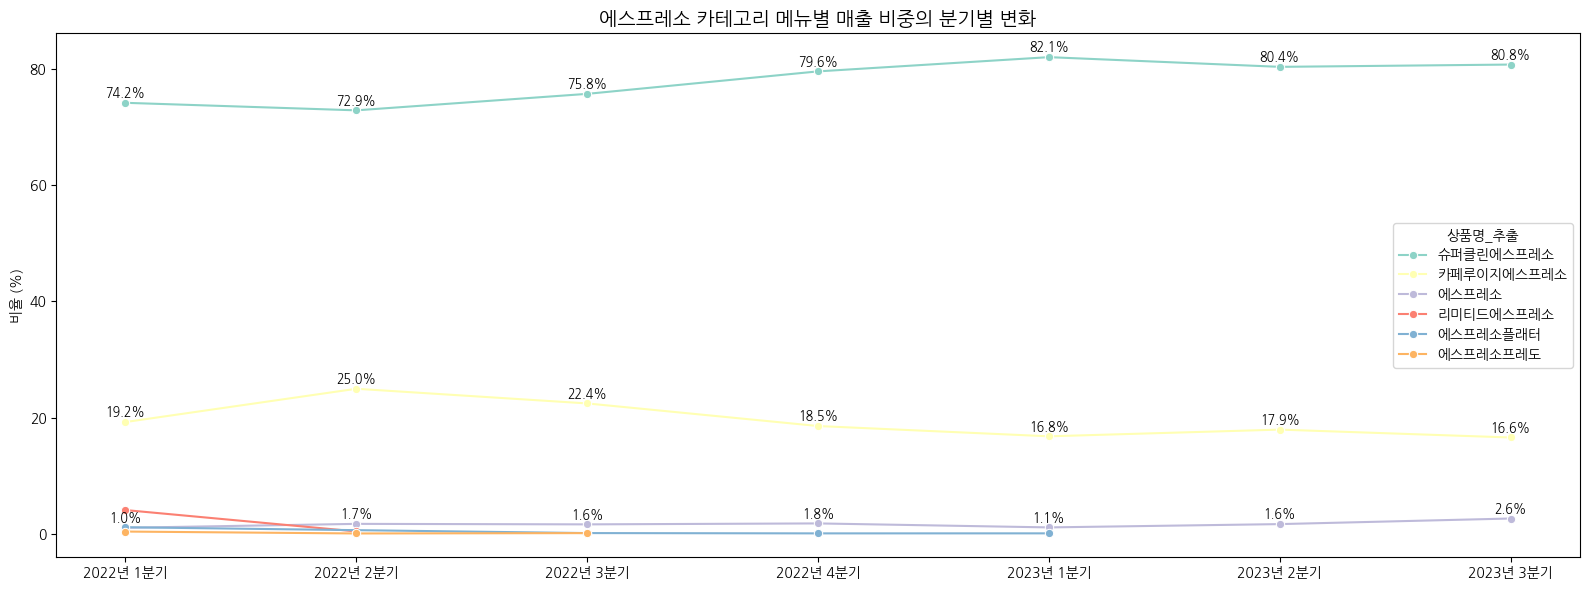

,결제분기,상품명_추출,매출,비율
0,2022년 1분기,리미티드에스프레소,552000,4.061960
1,2022년 1분기,슈퍼클린에스프레소,10088000,74.233783
2,2022년 1분기,에스프레소,137500,1.011811
3,2022년 1분기,에스프레소프레도,49000,0.360573
4,2022년 1분기,에스프레소플래터,150000,1.103793
5,2022년 1분기,카페루이지에스프레소,2613000,19.228081
6,2022년 2분기,리미티드에스프레소,84000,0.382688
7,2022년 2분기,슈퍼클린에스프레소,16009500,72.936219
8,2022년 2분기,에스프레소,370000,1.685649
9,2022년 2분기,에스프레소프레도,7000,0.031891


In [67]:
# 에스프레소 카테고리 메뉴별 매출 비중 분기별 변화
# 분기와 상품명별 매출을 집계한다.
quarterly_espresso_menu_rev = (
    espresso_sales_df
    .groupby(['결제분기', '상품명_추출'])['매출']
    .sum()
    .reset_index(name='매출')
)

# 각 분기 전체 에스프레소 매출 대비 메뉴별 매출 비중을 계산한다.
quarterly_espresso_menu_rev['비율'] = (
    quarterly_espresso_menu_rev['매출']
    / quarterly_espresso_menu_rev.groupby('결제분기')['매출'].transform('sum')
    * 100
)

# 분기와 상품명을 보기 좋은 순서로 정렬한다.
quarterly_espresso_menu_rev['결제분기'] = pd.Categorical(
    quarterly_espresso_menu_rev['결제분기'],
    categories=quarter_order,
    ordered=True,
)
espresso_menu_order = (
    espresso_sales_df
    .groupby('상품명_추출')['매출']
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# 에스프레소 카테고리 메뉴별 매출 비중의 분기별 변화 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=quarterly_espresso_menu_rev,
    x='결제분기',
    y='비율',
    hue='상품명_추출',
    hue_order=espresso_menu_order,
    marker='o',
    palette=sns.color_palette('Set3'),
)

# 비중이 큰 주요 메뉴는 점 위에 비율을 표시한다.
for _, row in quarterly_espresso_menu_rev.iterrows():
    if row['비율'] >= 15 or row['상품명_추출'] == espresso_menu_order[2]:
        plt.text(
            row['결제분기'],
            row['비율'] + 1,
            f"{row['비율']:.1f}%",
            ha='center',
            fontsize=9,
        )

plt.title('에스프레소 카테고리 메뉴별 매출 비중의 분기별 변화', fontsize=14)
plt.xlabel('')
plt.ylabel('비율 (%)')
plt.xticks(rotation=0)
plt.legend(title='상품명_추출', loc='center right')
plt.tight_layout()
plt.show()

quarterly_espresso_menu_rev

### 12. 매장 이용 형태별 구성 비율 

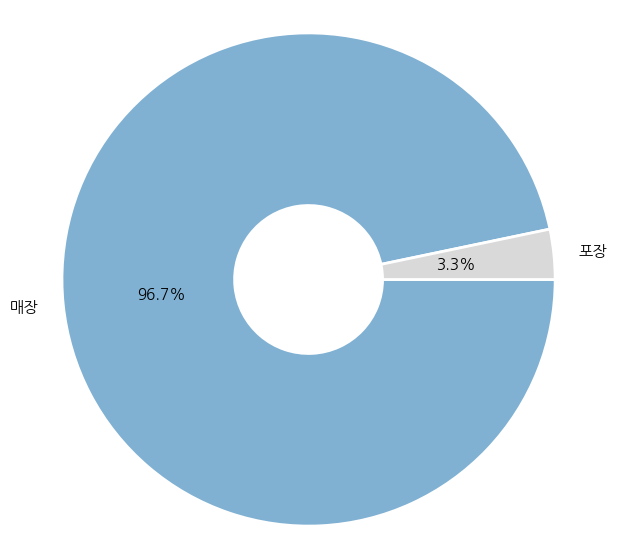

,매장 이용 형태,주문 건수,비율
0,매장,146355,96.723348
1,포장,4958,3.276652


In [78]:
# 매장 이용 형태별 구성 비율
# menu_sales_df 기준으로 취식 방법을 정리한다.
# '-'와 '야외'는 매장 이용으로 보고, '포장'은 그대로 유지한다.
store_use_df = menu_sales_df.copy()
store_use_df['매장 이용 형태'] = store_use_df['취식 방법'].replace({'-': '매장', '야외': '매장'})

# 매장 이용 형태별 주문 행 수와 구성 비율을 계산한다.
store_use_counts = (
    store_use_df['매장 이용 형태']
    .value_counts()
    .reindex(['매장', '포장'])
    .reset_index(name='주문 건수')
    .rename(columns={'매장 이용 형태': '매장 이용 형태'})
)
store_use_counts['비율'] = store_use_counts['주문 건수'] / store_use_counts['주문 건수'].sum() * 100

# 참고 이미지와 유사하게 매장은 파란색, 포장은 회색으로 표시한다.
store_use_colors = [sns.color_palette('Set3')[4], '#d9d9d9']

# 매장 이용 형태별 구성 비율 도넛 차트 시각화
plt.figure(figsize=(7, 7))
plt.pie(
    store_use_counts['주문 건수'],
    labels=store_use_counts['매장 이용 형태'],
    autopct='%.1f%%',
    startangle=0,
    counterclock=False,
    colors=store_use_colors,
    wedgeprops={'width': 0.7, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11},
)

plt.axis('equal')
plt.show()

store_use_counts

### 13. 매장 이용 형태별 누적 주문 건수 

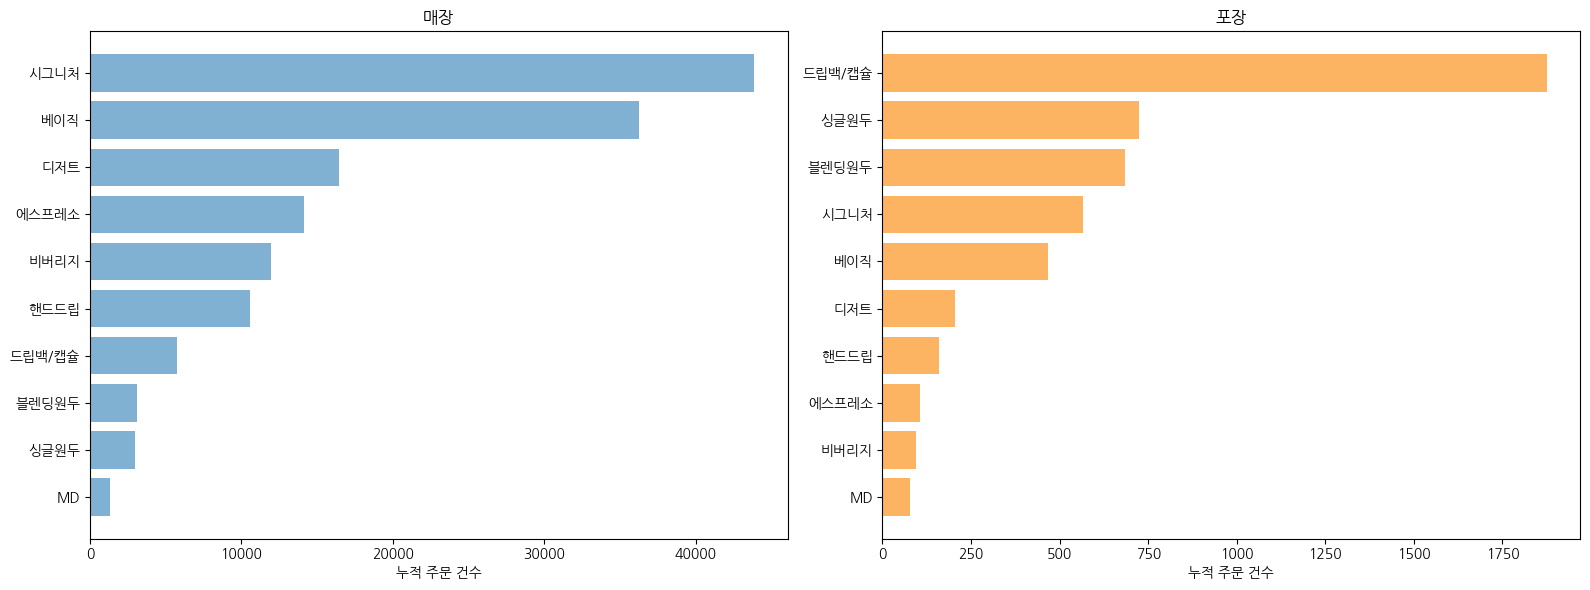

,매장 이용 형태,카테고리,누적 주문 건수,카테고리명
0,매장,Basic,36268,베이직
1,매장,MD,1312,MD
2,매장,드립백/캡슐,5747,드립백/캡슐
3,매장,디저트,16436,디저트
4,매장,블렌딩원두,3125,블렌딩원두
5,매장,비버리지,11956,비버리지
6,매장,시그니처,43873,시그니처
7,매장,싱글원두,2951,싱글원두
8,매장,에스프레소,14105,에스프레소
9,매장,핸드드립,10582,핸드드립


In [79]:
# 매장 이용 형태별 누적 주문 건수
# menu_sales_df에서 만든 매장/포장별 카테고리 주문 행 수를 집계한다.
store_use_category_order_cnt = (
    store_use_df
    .groupby(['매장 이용 형태', '카테고리'])
    .size()
    .reset_index(name='누적 주문 건수')
)

# 그래프 표기를 위해 Basic은 베이직으로 변경한다.
store_use_category_order_cnt['카테고리명'] = store_use_category_order_cnt['카테고리'].replace({'Basic': '베이직'})

# 매장과 포장 각각 주문 건수가 많은 순서대로 시각화한다.
store_order_plot_df = store_use_category_order_cnt.loc[store_use_category_order_cnt['매장 이용 형태'] == '매장'].sort_values('누적 주문 건수', ascending=True)
takeout_order_plot_df = store_use_category_order_cnt.loc[store_use_category_order_cnt['매장 이용 형태'] == '포장'].sort_values('누적 주문 건수', ascending=True)

# 참고 이미지와 유사하게 매장은 파란색, 포장은 주황색 계열로 표시한다.
store_bar_color = sns.color_palette('Set3')[4]
takeout_bar_color = sns.color_palette('Set3')[5]

# 매장 이용 형태별 카테고리 누적 주문 건수 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

axes[0].barh(store_order_plot_df['카테고리명'], store_order_plot_df['누적 주문 건수'], color=store_bar_color)
axes[0].set_title('매장')
axes[0].set_xlabel('누적 주문 건수')
axes[0].set_ylabel('')

axes[1].barh(takeout_order_plot_df['카테고리명'], takeout_order_plot_df['누적 주문 건수'], color=takeout_bar_color)
axes[1].set_title('포장')
axes[1].set_xlabel('누적 주문 건수')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

store_use_category_order_cnt

## 1-3. 카페 메뉴 연관성 분석

## 1-4. 방문인원단위 추정

In [36]:
# 방문 인원 단위 추정
# 결제일시가 같은 메뉴들을 한 주문 단위로 보고, 음료/방문 관련 메뉴 개수로 방문 인원 단위를 추정한다.
# 디저트, 원두, 드립백/캡슐, 사업자, MD는 방문 인원 추정에서 제외한다.
non_visit_categories = ['디저트', '싱글원두', '블렌딩원두', '드립백/캡슐', '사업자', 'MD']
visit_menu_df = cp_data_df.loc[~cp_data_df['카테고리'].isin(non_visit_categories)].copy()

# 방문 인원 추정에 사용된 카테고리 확인
visit_categories = visit_menu_df['카테고리'].unique()
print(visit_categories)

# 결제일시별 주문 메뉴 수를 방문 인원 단위로 집계
visit_unit_by_order_dt = visit_menu_df.groupby('결제일시').size().reset_index(name='방문 인원 단위')

# 방문 인원 단위별 방문 수 집계
visitor_unit_counts = (
    visit_unit_by_order_dt['방문 인원 단위']
    .value_counts()
    .sort_index()
    .reset_index(name='방문 수')
    .rename(columns={'방문 인원 단위': '인원(가정)'})
)

visitor_unit_counts

['핸드드립' '에스프레소' '시그니처' 'Basic' '비버리지' '세트']


,인원(가정),방문 수
0,1,20997
1,2,31019
2,3,7685
3,4,2214
4,5,505
5,6,120
6,7,33
7,8,15
8,9,4
9,10,2


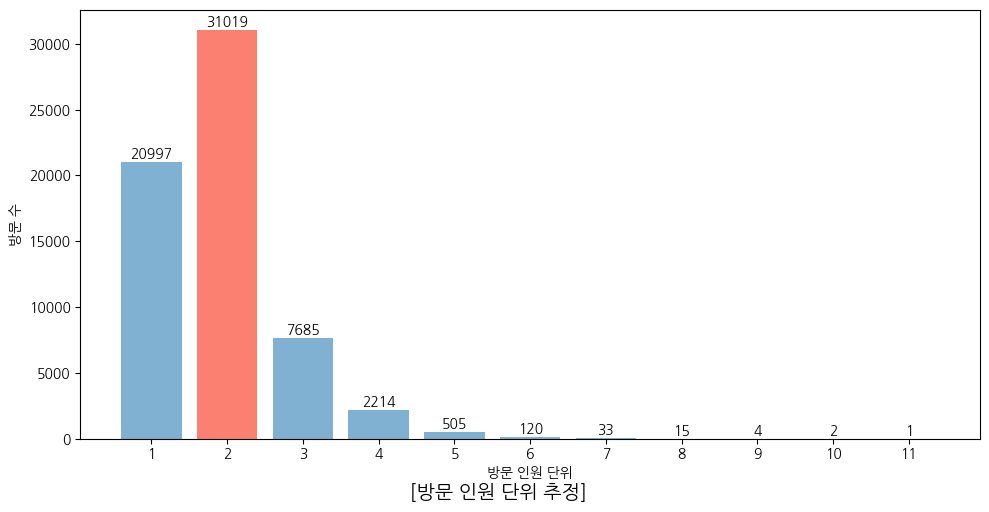

In [37]:
# 방문 인원 단위 분포 시각화
# 앞 셀에서 계산한 visitor_unit_counts를 사용해 하드코딩 없이 그래프를 생성한다.
visitor_unit_plot_df = visitor_unit_counts.copy()

# 2인 방문 추정값은 강조색으로, 나머지는 기본색으로 표시한다.
bar_colors = [
    sns.color_palette('Set3')[3] if visitor_unit == 2 else sns.color_palette('Set3')[4]
    for visitor_unit in visitor_unit_plot_df['인원(가정)']
]

plt.figure(figsize=(10, 5))
bars = plt.bar(visitor_unit_plot_df['인원(가정)'], visitor_unit_plot_df['방문 수'], color=bar_colors)

# x축을 방문 인원 단위별로 표시한다.
plt.xticks(ticks=visitor_unit_plot_df['인원(가정)'], labels=visitor_unit_plot_df['인원(가정)'])

# 각 막대 위에 방문 수를 표시한다.
for bar, visit_count in zip(bars, visitor_unit_plot_df['방문 수']):
    plt.text(bar.get_x() + bar.get_width() / 2, visit_count + 300, f'{visit_count}', ha='center')

plt.xlabel('방문 인원 단위')
plt.ylabel('방문 수')
plt.title('')
plt.figtext(0.5, -0.006, ' [방문 인원 단위 추정]', fontsize=14, ha='center')

plt.tight_layout()
plt.show()